<a href="https://colab.research.google.com/github/Princedevani01/artificial-intelligence/blob/main/artificial_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
# Function to Build the Neural Network Model
def build_model(hidden_activation):
    model = Sequential()

    # Input layer
    model.add(Flatten(input_shape=(28, 28)))

    # Six hidden layers
    model.add(Dense(128, activation=hidden_activation))
    model.add(Dense(128, activation=hidden_activation))
    model.add(Dense(64, activation=hidden_activation))
    model.add(Dense(64, activation=hidden_activation))
    model.add(Dense(32, activation=hidden_activation))
    model.add(Dense(32, activation=hidden_activation))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',        # Watch validation loss
    patience=3,                # Stop if no improvement for 3 epochs
    restore_best_weights=True  # Restore best model weights
)

In [5]:
# Train Model with Sigmoid Activation
sigmoid_model = build_model('sigmoid')

history_sigmoid = sigmoid_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


sigmoid_test_loss, sigmoid_test_accuracy = sigmoid_model.evaluate(
    X_test, y_test_cat, verbose=0
)

print("Sigmoid Test Accuracy:", sigmoid_test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1719 - loss: 2.1718 - val_accuracy: 0.3588 - val_loss: 1.5046
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4597 - loss: 1.3905 - val_accuracy: 0.6987 - val_loss: 0.9615
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7173 - loss: 0.8632 - val_accuracy: 0.7651 - val_loss: 0.6500
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7959 - loss: 0.6058 - val_accuracy: 0.8462 - val_loss: 0.4793
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8500 - loss: 0.4558 - val_accuracy: 0.8633 - val_loss: 0.3955
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8665 - loss: 0.3780 - val_accuracy: 0.8778 - val_loss: 0.3563
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8914 - loss: 0.3208 - val_accuracy: 0.9262 - val_loss: 0.3088
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9391 - loss: 0.2532 - val_accuracy: 0

In [7]:
# Train Model with Tanh Activation
tanh_model = build_model('tanh')

history_tanh = tanh_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


tanh_test_loss, tanh_test_accuracy = tanh_model.evaluate(
    X_test, y_test_cat, verbose=0
)

print("Tanh Test Accuracy:", tanh_test_accuracy)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8149 - loss: 0.7312 - val_accuracy: 0.9460 - val_loss: 0.1918
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9502 - loss: 0.1721 - val_accuracy: 0.9621 - val_loss: 0.1387
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9662 - loss: 0.1165 - val_accuracy: 0.9662 - val_loss: 0.1182
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9741 - loss: 0.0882 - val_accuracy: 0.9688 - val_loss: 0.1098
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9781 - loss: 0.0717 - val_accuracy: 0.9708 - val_loss: 0.1009
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9837 - loss: 0.0549 - val_accuracy: 0.9709 - val_loss: 0.1061
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9843 - loss: 0.0512 - val_accuracy: 0.9728 - val_loss: 0.0978
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - loss: 0.0387 - val_accuracy: 

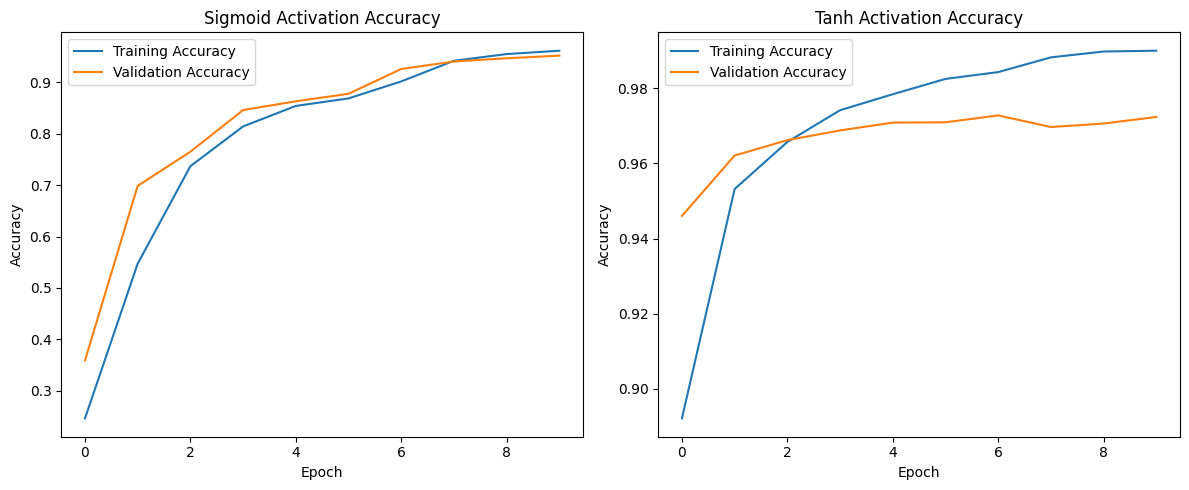

In [8]:
plt.figure(figsize=(12,5))

# Sigmoid accuracy
plt.subplot(1,2,1)
plt.plot(history_sigmoid.history['accuracy'], label='Training Accuracy')
plt.plot(history_sigmoid.history['val_accuracy'], label='Validation Accuracy')
plt.title('Sigmoid Activation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Tanh accuracy
plt.subplot(1,2,2)
plt.plot(history_tanh.history['accuracy'], label='Training Accuracy')
plt.plot(history_tanh.history['val_accuracy'], label='Validation Accuracy')
plt.title('Tanh Activation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

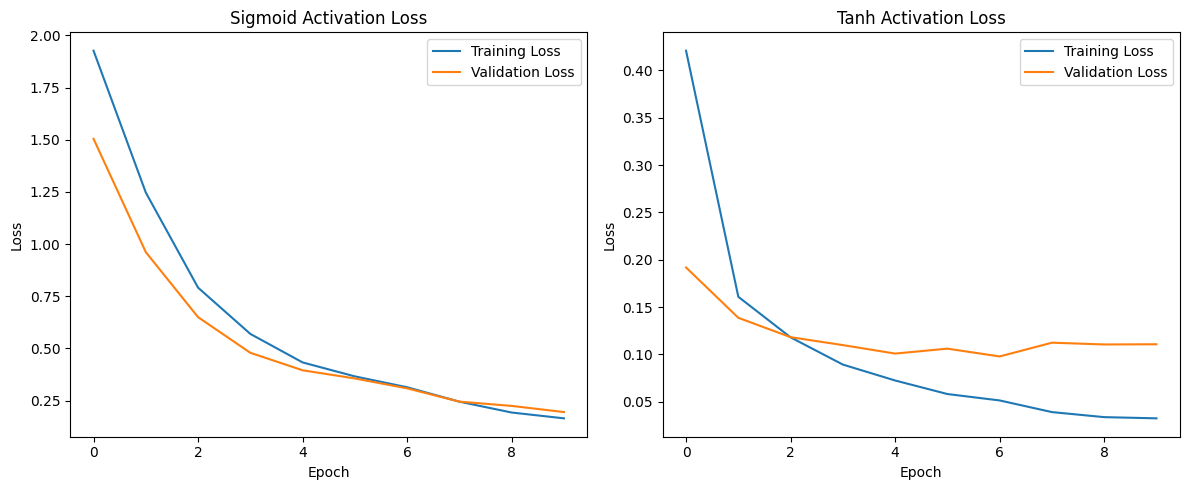

In [9]:
plt.figure(figsize=(12,5))

# Sigmoid loss
plt.subplot(1,2,1)
plt.plot(history_sigmoid.history['loss'], label='Training Loss')
plt.plot(history_sigmoid.history['val_loss'], label='Validation Loss')
plt.title('Sigmoid Activation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Tanh loss
plt.subplot(1,2,2)
plt.plot(history_tanh.history['loss'], label='Training Loss')
plt.plot(history_tanh.history['val_loss'], label='Validation Loss')
plt.title('Tanh Activation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
print("Final Comparison")
print(f"Sigmoid Test Accuracy: {sigmoid_test_accuracy:.4f}")
print(f"Tanh Test Accuracy:    {tanh_test_accuracy:.4f}")

Final Comparison
Sigmoid Test Accuracy: 0.9522
Tanh Test Accuracy:    0.9740


In [11]:
def visualize_predictions(model, X_test, y_test, num_images=5):
    """
    Visualize sample predictions with confidence scores
    """
    # Randomly select images
    indices = np.random.choice(len(X_test), num_images, replace=False)

    # Get predictions
    predictions = model.predict(X_test[indices])

    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(X_test[idx], cmap='gray')
        plt.axis('off')

        true_label = y_test[idx]
        predicted_label = np.argmax(predictions[i])
        confidence = np.max(predictions[i]) * 100

        plt.title(
            f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.1f}%",
            fontsize=10
        )

    plt.suptitle("Sample MNIST Predictions with Confidence", fontsize=14)
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


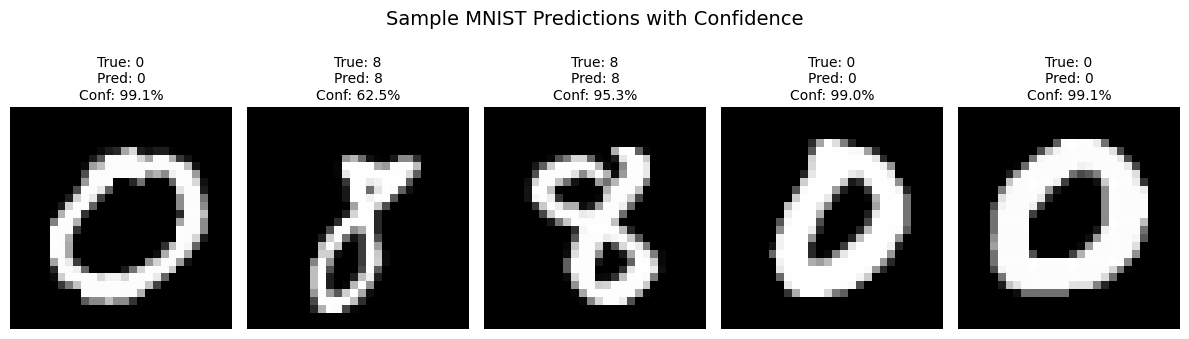

In [12]:
visualize_predictions(
    model=sigmoid_model,
    X_test=X_test,
    y_test=y_test,
    num_images=5
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


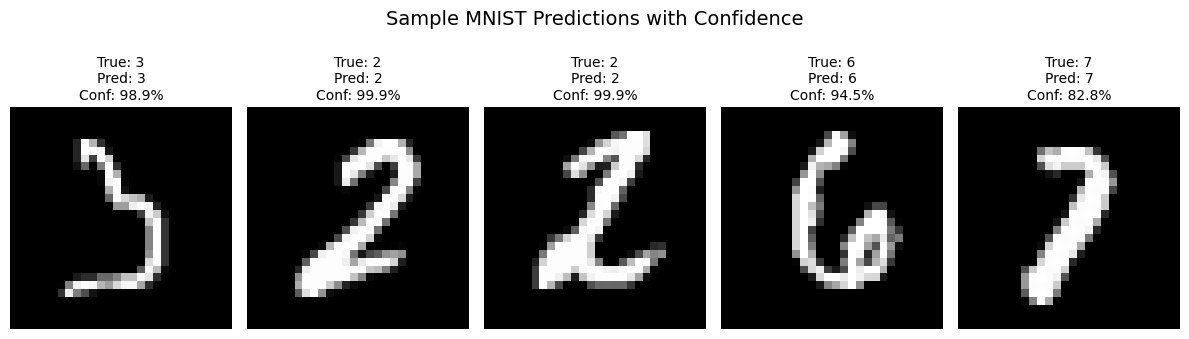

In [13]:
visualize_predictions(
    model=tanh_model,
    X_test=X_test,
    y_test=y_test,
    num_images=5
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


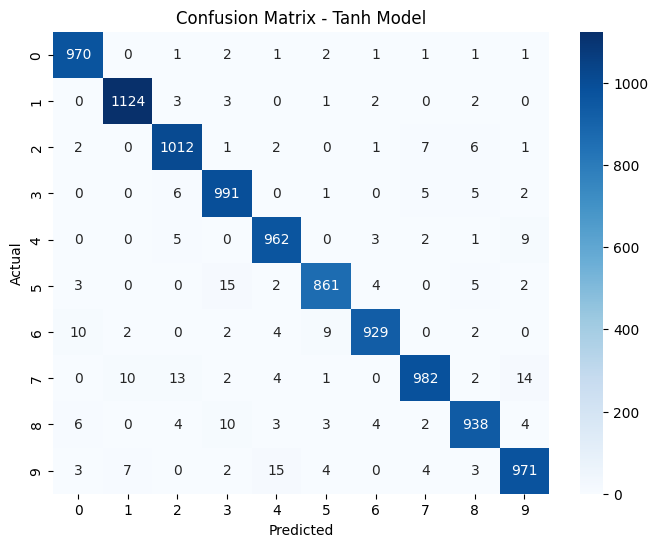

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict labels
y_pred_tanh = np.argmax(tanh_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred_tanh)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tanh Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total Misclassified: 260


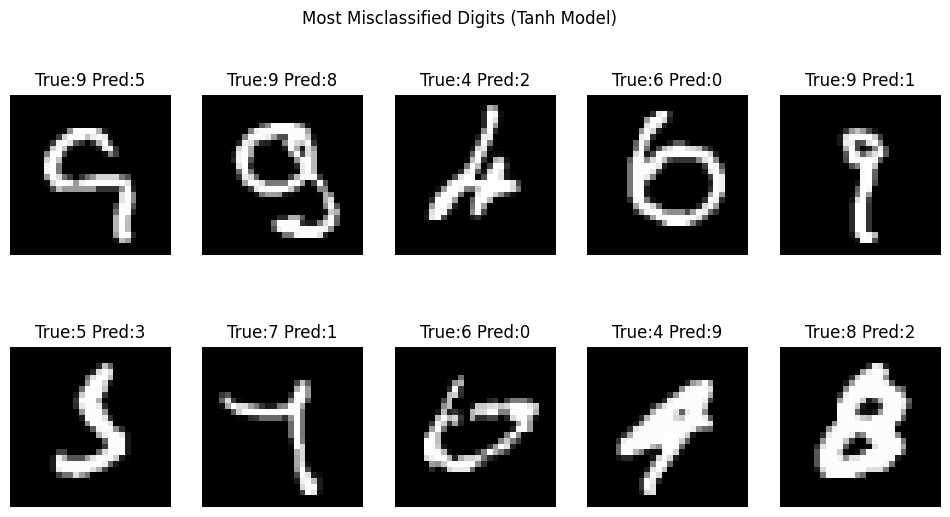

In [15]:
# Identify misclassified samples (Tanh model example)

y_pred_tanh = np.argmax(tanh_model.predict(X_test), axis=1)

misclassified_indices = np.where(y_pred_tanh != y_test)[0]

print("Total Misclassified:", len(misclassified_indices))

# Display 10 most misclassified samples
plt.figure(figsize=(12,6))

for i, idx in enumerate(misclassified_indices[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True:{y_test[idx]} Pred:{y_pred_tanh[idx]}")
    plt.axis('off')

plt.suptitle("Most Misclassified Digits (Tanh Model)")
plt.show()

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

def build_hybrid_model():
    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    # Mixed activations
    model.add(Dense(128, activation='tanh'))
    model.add(Dense(128, activation='sigmoid'))
    model.add(Dense(64, activation='tanh'))
    model.add(Dense(64, activation='sigmoid'))
    model.add(Dense(32, activation='tanh'))
    model.add(Dense(32, activation='sigmoid'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

hybrid_model = build_hybrid_model()

history_hybrid = hybrid_model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(X_test, y_test_cat)
print("Hybrid Model Accuracy:", hybrid_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4613 - loss: 1.6571 - val_accuracy: 0.8953 - val_loss: 0.5396
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9102 - loss: 0.4268 - val_accuracy: 0.9458 - val_loss: 0.2440
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9509 - loss: 0.2158 - val_accuracy: 0.9548 - val_loss: 0.1945
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9607 - loss: 0.1627 - val_accuracy: 0.9629 - val_loss: 0.1525
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9721 - loss: 0.1173 - val_accuracy: 0.9660 - val_loss: 0.1371
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9781 - loss: 0.0914 - val_accuracy: 0.9652 - val_loss: 0.1401
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9818 - loss: 0.0737 - val_accuracy: 0.9672 - val_loss: 0.1316
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9835 - loss: 0.0653 - val_accuracy: 0.